Pipline ML:
- Exploratory data analysis
    - see the data types
    - df.describe()
    - find anomalies
    - find none value
- Data Preprocessing
    - del unnecesary
    - str / bool to int
    - one code encoding
- Var Selection
- ML model Building
- ML evaluation

---------------------------------------------------------------------------

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df_test = pd.read_csv("test.csv")
df_train = pd.read_csv("train.csv")

In [4]:
df_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


1. Age has null values
2. Low survivability
3. More high-class than lowclass

In [9]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
woman = df_train.loc[df_train.Sex == 'female']["Survived"]
rate_woman = sum(woman) / len(woman)
print("% of women survived: ", round(rate_woman * 100, 1))

man = df_train.loc[df_train.Sex == 'male']["Survived"]
rate_man = sum(man) / len(man)
print("% of men survived: ", round(rate_man * 100, 1))

% of women survived:  74.2
% of men survived:  18.9


In [13]:
val = {"male": 1, "female": 0}
val1 = {"S": 1, "C": 2, "Q": 3}
df_train["Sex"] = df_train["Sex"].map(val)
df_train["Embarked"] = df_train["Embarked"].map(val1)
df_train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,1.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,2.0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,1.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,1.0
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",1,27.0,0,0,211536,13.0000,NaN,1.0
887,888,1,1,"Graham, Miss. Margaret Edith",0,19.0,0,0,112053,30.0000,B42,1.0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,NaN,1,2,W./C. 6607,23.4500,NaN,1.0
889,890,1,1,"Behr, Mr. Karl Howell",1,26.0,0,0,111369,30.0000,C148,2.0


In [15]:
df_train = df_train.drop(["Name", "Cabin", "Ticket"], axis = 1)

In [17]:
df_train['Age'] = df_train['Age'].fillna(df_train['Age'].mean())
df_train

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,1,22.000000,1,0,7.2500,1.0
1,2,1,1,0,38.000000,1,0,71.2833,2.0
2,3,1,3,0,26.000000,0,0,7.9250,1.0
3,4,1,1,0,35.000000,1,0,53.1000,1.0
4,5,0,3,1,35.000000,0,0,8.0500,1.0
...,...,...,...,...,...,...,...,...,...
886,887,0,2,1,27.000000,0,0,13.0000,1.0
887,888,1,1,0,19.000000,0,0,30.0000,1.0
888,889,0,3,0,29.699118,1,2,23.4500,1.0
889,890,1,1,1,26.000000,0,0,30.0000,2.0


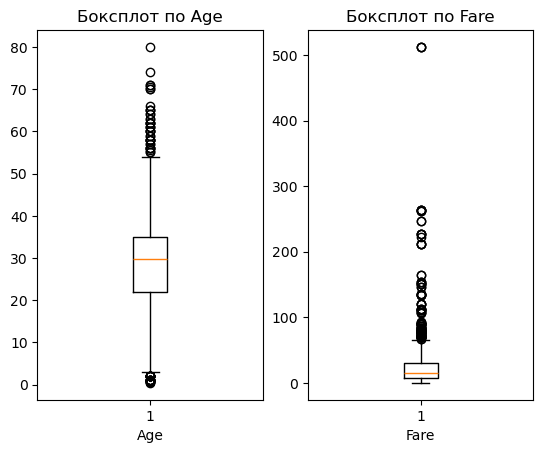

In [19]:
plt.subplot(1, 2, 1)
plt.boxplot(x = [df_train["Age"]])
plt.title('Боксплот по Age')
plt.xlabel('Age')

plt.subplot(1, 2, 2)
plt.boxplot(x = [df_train["Fare"]])
plt.title('Боксплот по Fare')
plt.xlabel('Fare')
plt.show()

In [21]:
df_train = df_train.dropna(subset = ["Embarked"])

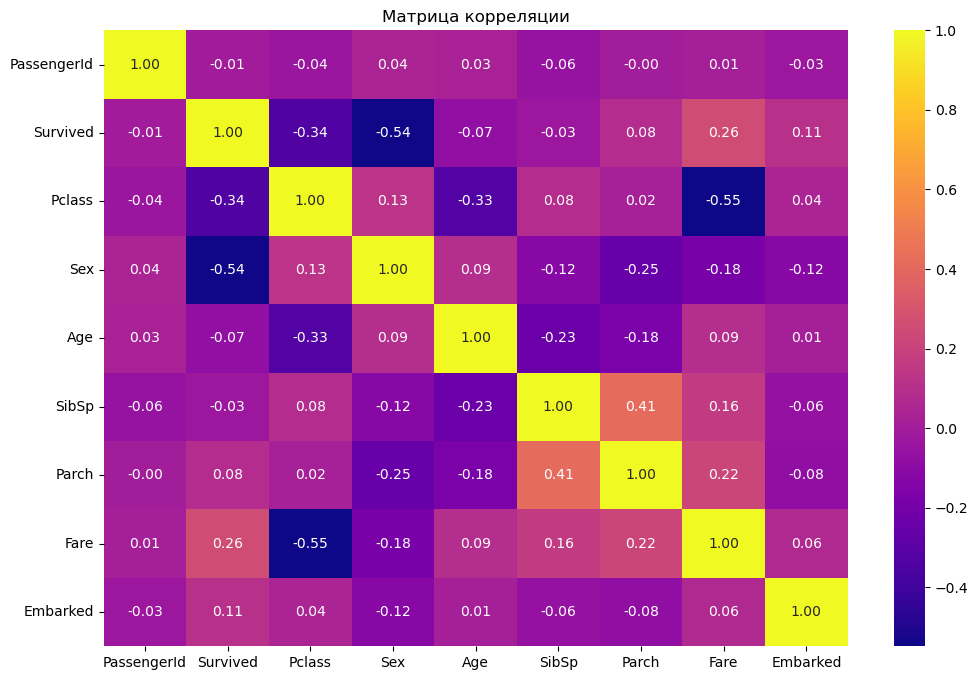

In [23]:
# Матрица корреляции
plt.figure(figsize=(12, 8))
sns.heatmap(df_train.corr(), annot=True, cmap='plasma', fmt='.2f')
plt.title('Матрица корреляции')
plt.show()

In [25]:
val = {"male": 1, "female": 0}
val1 = {"S": 1, "C": 2, "Q": 3}
df_test ["Sex"] = df_test ["Sex"].map(val)
df_test ["Embarked"] = df_test ["Embarked"].map(val1)
df_test = df_test .drop(["Name", "Cabin", "Ticket"], axis = 1)
df_test ['Age'] = df_test ['Age'].fillna(df_test ['Age'].mean())
df_test  = df_test .dropna(subset = ["Embarked"])

In [27]:
df_test.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,892,3,1,34.5,0,0,7.8292,3
1,893,3,0,47.0,1,0,7.0000,1
2,894,2,1,62.0,0,0,9.6875,3
3,895,3,1,27.0,0,0,8.6625,1
4,896,3,0,22.0,1,1,12.2875,1


In [29]:
#Separating data: x - the parameters, y - the goal
#Separating the data into the validation and train
from sklearn.model_selection import train_test_split
X = df_train.drop(["Survived"], axis = 1)
y = df_train["Survived"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
#fitting the data to into a standard range
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [97]:
#teaching the model using logistical regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
model = LogisticRegression(
    C=0.01,                # Сила регуляризации
    penalty='l1',         # Тип регуляризации
    max_iter=1000,       # Максимальное количество итераций
    solver='liblinear',   # Алгоритм оптимизации
    class_weight='balanced', # Учет несбалансированных классов
    random_state=42       # Для воспроизводимости
)  # Увеличиваем max_iter
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_val_scaled) #predicting on the validation selectio
accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy: {accuracy}") 

Accuracy: 0.797752808988764


In [111]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Создаем модель случайного леса
model = RandomForestClassifier(
    n_estimators=1000,      # Количество деревьев в лесу
    max_depth=None,        # Максимальная глубина дерева, None означает, что узлы будут расширяться до остановки
    min_samples_split=2,   # Минимальное количество образцов для разделения узла
    min_samples_leaf=3,    # Минимальное количество образцов в листовом узле
    class_weight='balanced', # Учет несбалансированных классов
    random_state=42        # Для воспроизводимости
)

# Обучаем модель
model.fit(X_train_scaled, y_train)

# Прогнозируем на валидационном наборе
y_pred = model.predict(X_val_scaled)

# Оценка точности
accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy: {accuracy}")  # Выводим точность 

Accuracy: 0.797752808988764
